<a href="https://colab.research.google.com/github/FernandaChacara/AVCAD/blob/main/Exercise7/EFIplus_cluster_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/FernandaChacara/AVCAD/blob/main/Exercise7/EFIplus_cluster_analysis_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EFIplus Mediterranean dataset — Cluster Analysis

This notebook solves the exercise:

1. Run agglomerative cluster analysis using different linkage methods based on quantitative environmental variables, using sites from the **Douro** and **Tejo** basins.
2. Plot a heatmap and dendrogram by clustering the rows/sites using **average linkage**.
3. Plot a dendrogram that clusters the environmental variables/columns using **average linkage** and discuss how this helps variable selection for regression-based analysis.




In [1]:
# Install/import required packages
import os
import glob
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the dataset

The cell below searches for the zip file. If it is not already available, it downloads the zip from the GitHub repository.


In [2]:
# Try to find the dataset zip file locally
possible_zips = glob.glob("*.zip") + glob.glob("**/*.zip", recursive=True)
possible_zips = [z for z in possible_zips if "EFIplus_medit" in os.path.basename(z)]

if possible_zips:
    zip_path = possible_zips[0]
    print(f"Found local zip file: {zip_path}")
else:
    # Try to download from GitHub raw URLs
    urls = [
        "https://raw.githubusercontent.com/FernandaChacara/AVCAD/main/Exercise7/EFIplus_medit.zip",
        "https://raw.githubusercontent.com/FernandaChacara/AVCAD/main/Exercise7/EFIplus_medit%20(2).zip",
        "https://github.com/FernandaChacara/AVCAD/raw/main/Exercise7/EFIplus_medit.zip",
        "https://github.com/FernandaChacara/AVCAD/raw/main/Exercise7/EFIplus_medit%20(2).zip",
    ]
    zip_path = "EFIplus_medit.zip"
    downloaded = False
    for url in urls:
        try:
            print(f"Trying to download: {url}")
            urllib.request.urlretrieve(url, zip_path)
            downloaded = True
            print(f"Downloaded dataset to: {zip_path}")
            break
        except Exception as e:
            print(f"Could not download from this URL. Error: {e}")

    if not downloaded:
        raise FileNotFoundError(
            "Could not find or download the dataset. Please upload EFIplus_medit.zip to Colab and run again."
        )

# Extract zip
extract_dir = "EFIplus_medit_extracted"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Extracted files:")
for file in glob.glob(extract_dir + "/**/*", recursive=True):
    if os.path.isfile(file):
        print(file)


Trying to download: https://raw.githubusercontent.com/FernandaChacara/AVCAD/main/Exercise7/EFIplus_medit.zip
Could not download from this URL. Error: HTTP Error 404: Not Found
Trying to download: https://raw.githubusercontent.com/FernandaChacara/AVCAD/main/Exercise7/EFIplus_medit%20(2).zip
Downloaded dataset to: EFIplus_medit.zip
Extracted files:
EFIplus_medit_extracted/EFIplus_medit.csv


In [3]:
# Find tabular files inside extracted folder
candidate_files = []
for ext in ["*.csv", "*.txt", "*.tsv", "*.xls", "*.xlsx"]:
    candidate_files.extend(glob.glob(extract_dir + f"/**/*{ext[1:]}", recursive=True))

print("Candidate data files:")
for f in candidate_files:
    print(f)

if not candidate_files:
    raise FileNotFoundError("No CSV/TXT/TSV/XLS/XLSX file found inside the zip.")

# Read the first suitable file
file_path = candidate_files[0]
print(f"\nReading: {file_path}")

if file_path.endswith((".xls", ".xlsx")):
    df = pd.read_excel(file_path)
else:
    # sep=None lets pandas infer separator, works for comma/semicolon/tab in most cases
    df = pd.read_csv(file_path, sep=None, engine="python")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Candidate data files:
EFIplus_medit_extracted/EFIplus_medit.csv

Reading: EFIplus_medit_extracted/EFIplus_medit.csv
Dataset loaded successfully.
Shape: (5011, 164)


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Clean column names, just in case there are spaces around them
df.columns = df.columns.str.strip()

print("Columns in the dataset:")
for col in df.columns:
    print(col)


Columns in the dataset:
Site_code
Latitude
Longitude
Country
Catchment_name
Galiza
Subsample
Calib_EFI_Medit
Calib_connect
Calib_hydrol
Calib_morphol
Calib_wqual
Geomorph1
Geomorph2
Geomorph3
Water_source_type
Flow_regime
Altitude
Geological_typology
Actual_river_slope
Natural_sediment
Elevation_mean_catch
prec_ann_catch
temp_ann
temp_jan
temp_jul
Barriers_catchment_down
Barriers_river_segment_up
Barriers_river_segment_down
Barriers_number_river_segment_up
Barriers_number_river_segment_down
Barriers_distance_river_segment_up
Barriers_distance_river_segment_down
Impoundment
Hydropeaking
Water_abstraction
Hydro_mod
Temperature_impact
Velocity_increase
Reservoir_flushing
Sedimentation
Channelisation
Cross_sec
Instream_habitat
Riparian_vegetation
Embankment
Floodprotection
Floodplain
Toxic_substances
Acidification
Water_quality_index
Eutrophication
Organic_pollution
Organic_siltation
Sum of Run1_number_all
Total_sp
Abramis brama
Achondrostoma arcasii
Achondrostoma occidentale
Achondrostoma

## 2. Select Douro and Tejo sites and quantitative environmental variables

The quantitative environmental variables used are the same as in the previous exercises:

- `Altitude`
- `Actual_river_slope`
- `Elevation_mean_catch`
- `prec_ann_catch`
- `temp_ann`
- `temp_jan`
- `temp_jul`


In [5]:
# Quantitative environmental variables from the previous exercises
quant_env_vars = [
    "Altitude",
    "Actual_river_slope",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul"
]

# Check required columns
required_cols = ["Catchment_name"] + quant_env_vars
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"These required columns are missing from the dataset: {missing_cols}")

# Filter Douro and Tejo only
basins = ["Douro", "Tejo"]
df_dt = df[df["Catchment_name"].isin(basins)].copy()

# Keep only group variable + environmental variables and remove missing values
df_dt = df_dt[["Catchment_name"] + quant_env_vars].dropna().reset_index(drop=True)

print("Filtered dataset shape:", df_dt.shape)
print(df_dt["Catchment_name"].value_counts())
df_dt.head()


Filtered dataset shape: (888, 8)
Catchment_name
Tejo     493
Douro    395
Name: count, dtype: int64


,Catchment_name,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
0,Tejo,1253,13.406,1603.519424,640.327779,9.3,0.6,18.9
1,Tejo,1155,9.398,1578.678579,633.238847,10.1,1.2,19.6
2,Tejo,1074,8.186,1553.219128,625.841858,10.1,1.2,19.5
3,Tejo,1018,11.736,1539.684999,622.111415,10.3,1.7,20.0
4,Tejo,979,2.670,1493.914010,608.146170,10.6,1.8,20.2


In [6]:
# Standardize environmental variables before clustering
# This is important because variables have different units and scales.
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_dt[quant_env_vars]),
    columns=quant_env_vars,
    index=df_dt.index
)

groups = df_dt["Catchment_name"]

print("Standardized environmental data:")
X_scaled.head()


Standardized environmental data:


,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
0,1.977157,0.083440,1.819874,-0.568930,-1.884845,-1.844771,-1.456903
1,1.703876,-0.126266,1.758331,-0.594745,-1.528436,-1.628612,-1.121913
2,1.478000,-0.189680,1.695256,-0.621683,-1.528436,-1.628612,-1.169769
3,1.321839,-0.003937,1.661725,-0.635268,-1.439333,-1.448480,-0.930491
4,1.213084,-0.478288,1.548328,-0.686126,-1.305680,-1.412454,-0.834779


## 3. Agglomerative cluster analysis with different linkage methods

The following dendrograms compare how the sites are clustered using different linkage methods.

- **Single linkage**: based on the closest pair of observations between clusters.
- **Complete linkage**: based on the farthest pair of observations between clusters.
- **Average linkage**: based on the average distance between observations in clusters.
- **Ward linkage**: minimizes within-cluster variance.


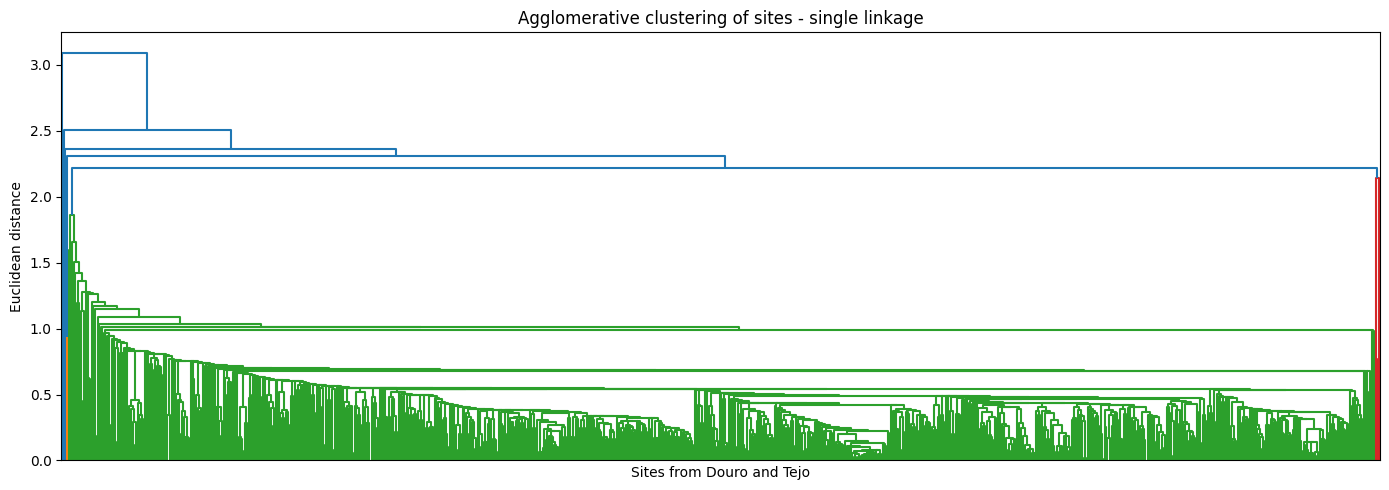

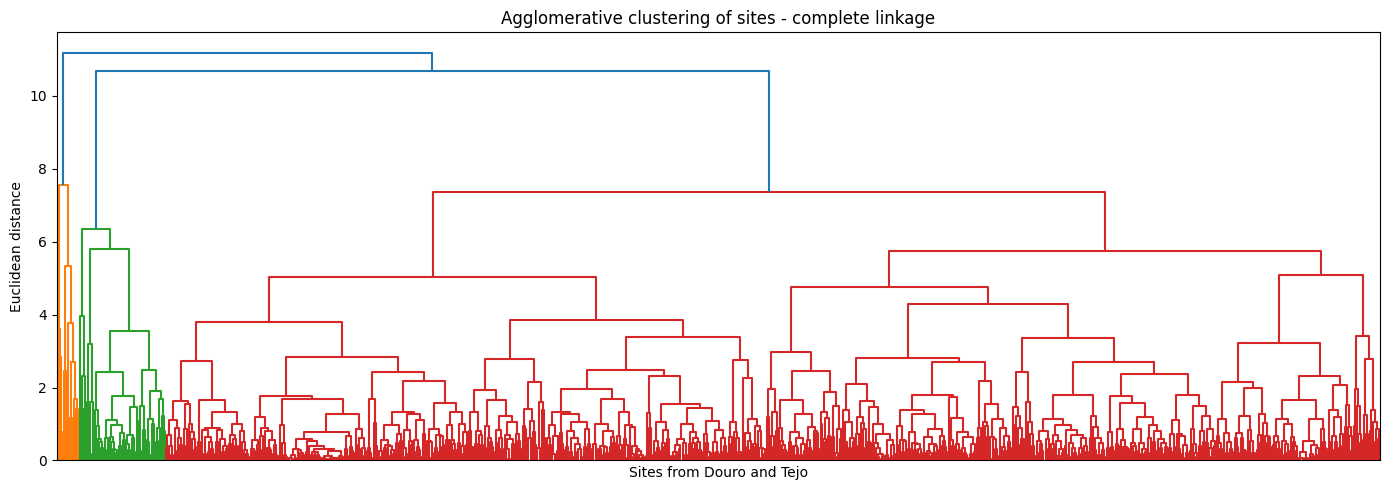

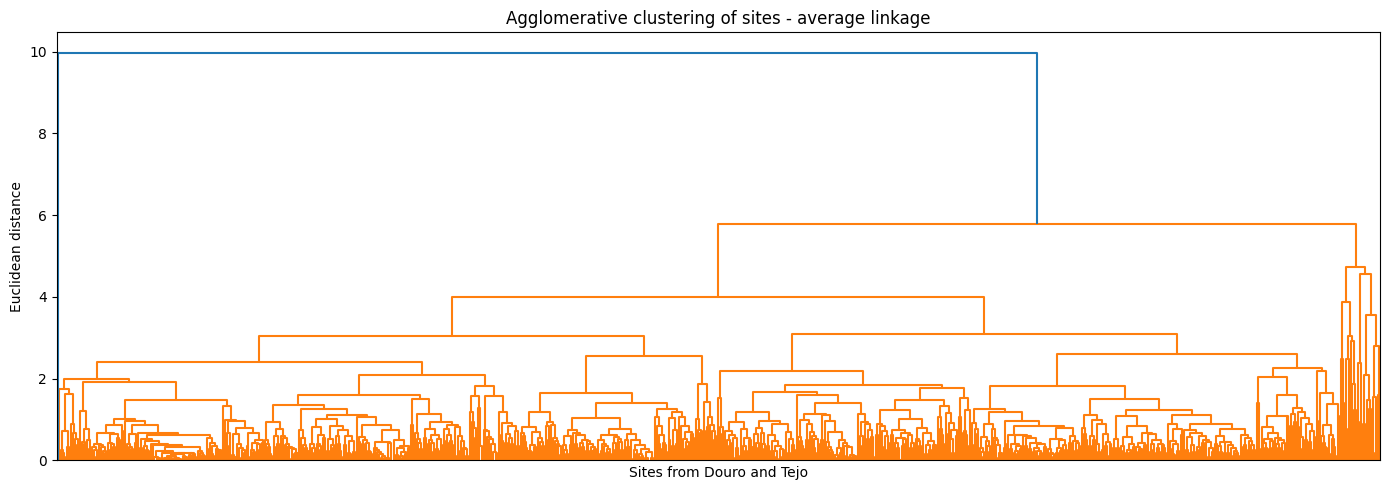

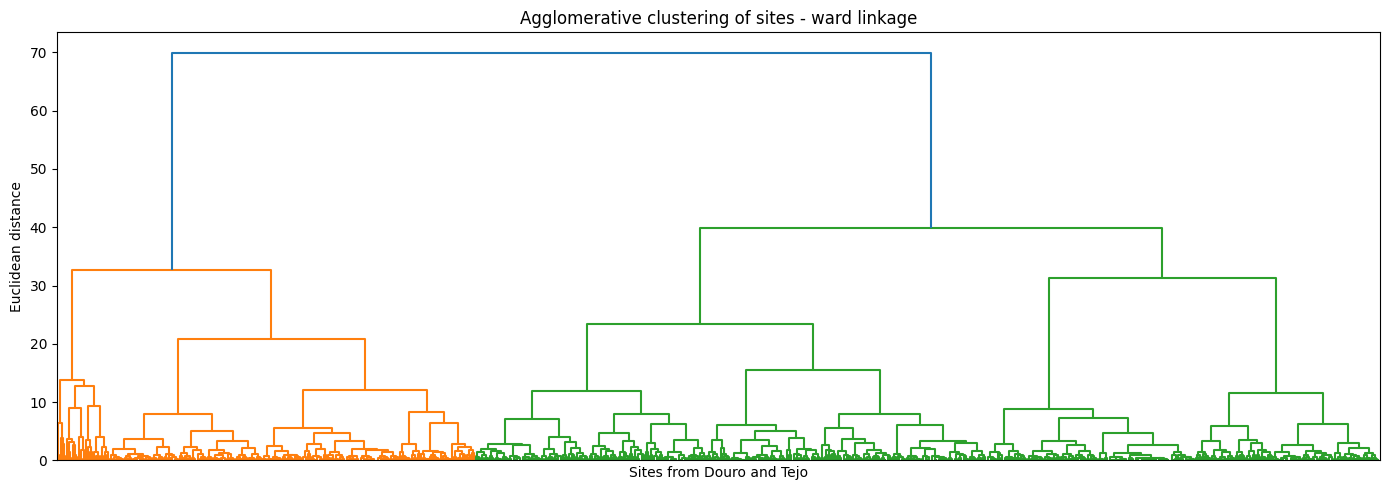

In [7]:
# Different linkage methods for site clustering
linkage_methods = ["single", "complete", "average", "ward"]

for method in linkage_methods:
    Z = linkage(X_scaled, method=method, metric="euclidean")

    plt.figure(figsize=(14, 5))
    dendrogram(
        Z,
        no_labels=True,
        color_threshold=None
    )
    plt.title(f"Agglomerative clustering of sites - {method} linkage")
    plt.xlabel("Sites from Douro and Tejo")
    plt.ylabel("Euclidean distance")
    plt.tight_layout()
    plt.show()


## 4. Heatmap and dendrogram clustering rows/sites using average linkage

The rows are the sites and the columns are the standardized environmental variables. The row colour indicates the catchment/basin.

The site names are intentionally hidden because there are many observations; showing all labels would make the graph unreadable.


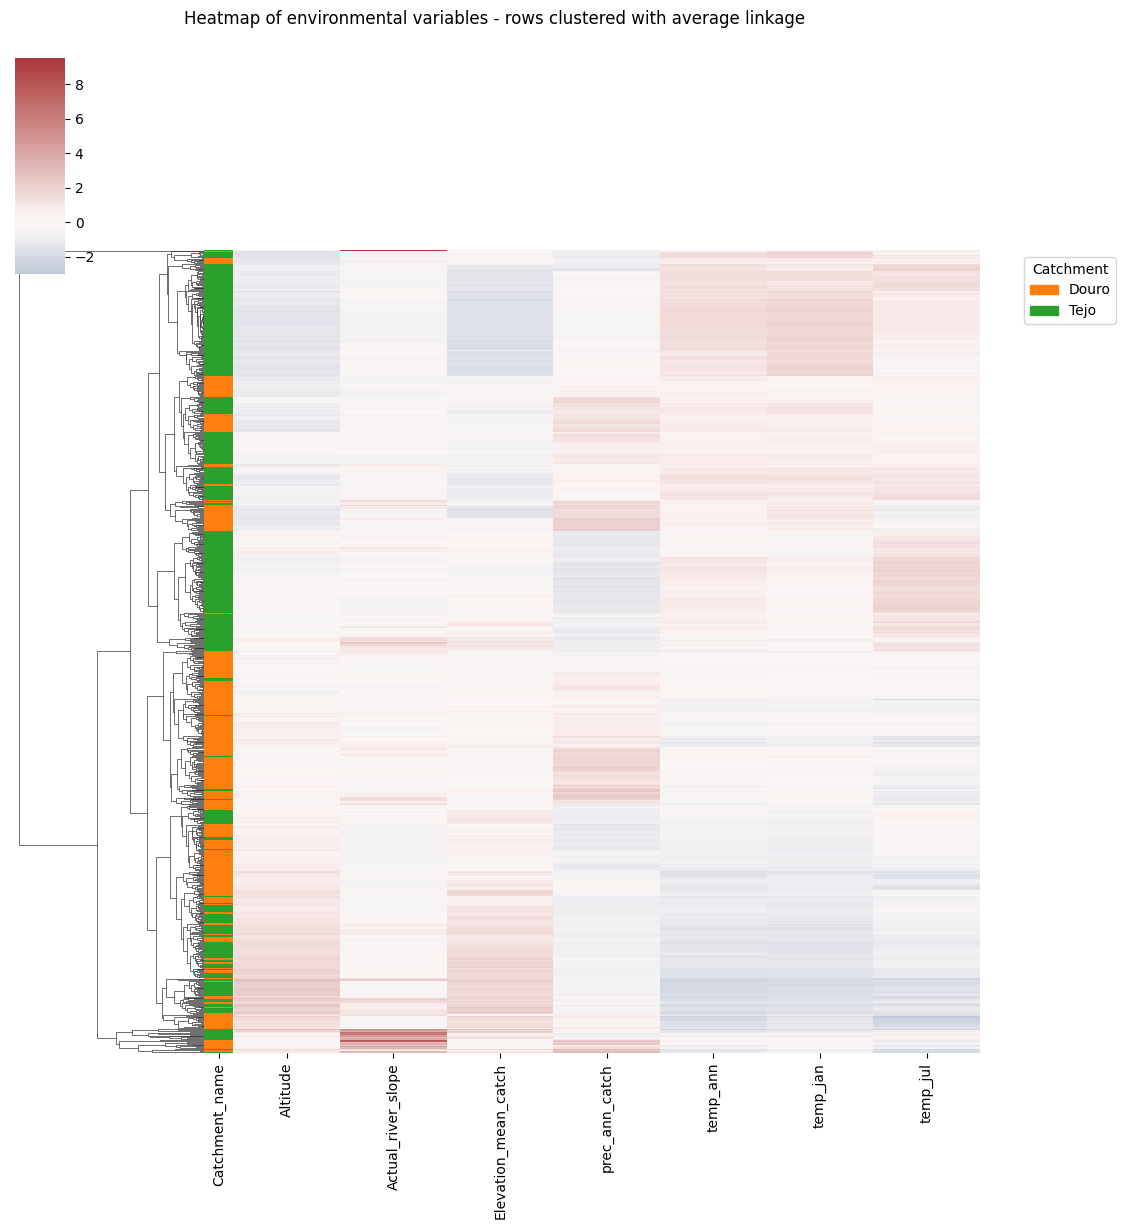

In [8]:
# Heatmap with rows/sites clustered using average linkage
# This cell is self-contained and should run without needing variables other than df_dt and X_scaled above.

catchment_palette = {
    "Douro": "tab:orange",
    "Tejo": "tab:green"
}

row_colors = df_dt["Catchment_name"].map(catchment_palette)

# Clustered heatmap
# row_cluster=True clusters sites/rows
# col_cluster=False keeps variables in their original order for readability

g = sns.clustermap(
    X_scaled,
    method="average",
    metric="euclidean",
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    cmap="vlag",
    center=0,
    figsize=(10, 12),
    yticklabels=False
)

# Add legend for catchments
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color=color, label=name)
    for name, color in catchment_palette.items()
]

g.ax_heatmap.legend(
    handles=handles,
    title="Catchment",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

g.fig.suptitle(
    "Heatmap of environmental variables - rows clustered with average linkage",
    y=1.02
)

plt.show()


## 5. Dendrogram clustering environmental variables/columns using average linkage

To cluster variables instead of sites, the environmental dataframe is transposed using `.T`.

This means that variables become the observations being clustered.


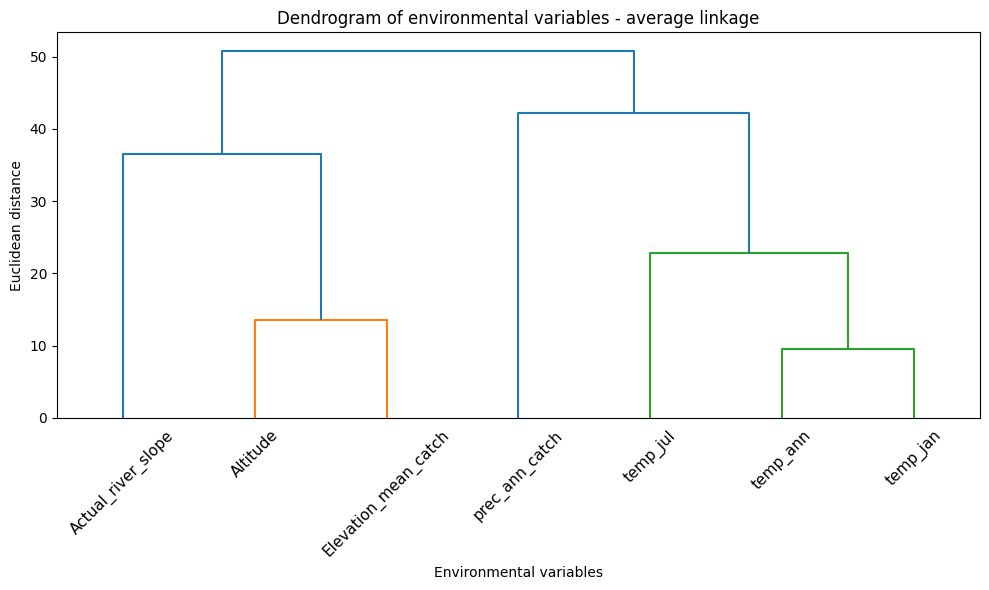

In [9]:
# Cluster environmental variables/columns using average linkage
# Transpose the dataframe so that variables become the rows to be clustered.

X_variables = X_scaled.T

Z_vars = linkage(X_variables, method="average", metric="euclidean")

plt.figure(figsize=(10, 6))
dendrogram(
    Z_vars,
    labels=X_variables.index,
    leaf_rotation=45,
    leaf_font_size=11
)
plt.title("Dendrogram of environmental variables - average linkage")
plt.xlabel("Environmental variables")
plt.ylabel("Euclidean distance")
plt.tight_layout()
plt.show()


## 6. Discussion

The clustering of sites shows how sampling locations from the Douro and Tejo basins group according to their environmental characteristics. Because the variables were standardized before the analysis, the clustering is not dominated by variables with larger numerical scales, such as altitude or precipitation.

The heatmap helps visualize which environmental gradients are associated with each cluster of sites. Sites that appear close together in the dendrogram have similar environmental profiles across altitude, slope, catchment elevation, precipitation and temperature variables. The lateral colour bar allows us to see whether the environmental clusters correspond clearly to the Douro and Tejo basins or whether sites from both basins overlap environmentally.

The dendrogram of environmental variables is useful for variable selection in regression-based analysis. Variables that cluster very closely contain similar information and may be strongly correlated. For example, if annual temperature, January temperature and July temperature appear close together, they may represent the same broader temperature gradient. In a regression model, using many highly similar predictors can create multicollinearity, making coefficients unstable and harder to interpret. Therefore, the variable dendrogram can help select a smaller and less redundant set of predictors, choosing one representative variable from each cluster of similar environmental variables.
